In [2]:
%pip install wooldridge

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import pandas as pd
import numpy as np

import wooldridge as wd

sleep75 = wd.data("sleep75")

print("Dataset shape:", sleep75.shape)
print("\nFirst rows:")
print(sleep75.head())

print("\nVariable types:")
print(sleep75.dtypes)

print("\nMissing values:")
print(sleep75.isna().sum().sort_values(ascending=False))

Dataset shape: (706, 34)

First rows:
   age  black  case  clerical  construc  educ  earns74  gdhlth  inlf  leis1  \
0   32      0     1       0.0       0.0    12      0.0       0     1   3529   
1   31      0     2       0.0       0.0    14   9500.0       1     1   2140   
2   44      0     3       0.0       0.0    17  42500.0       1     1   4595   
3   30      0     4       0.0       0.0    12  42500.0       1     1   3211   
4   64      0     5       0.0       0.0    14   2500.0       1     1   4052   

   ...  spwrk75  totwrk  union  worknrm  workscnd  exper  yngkid  yrsmarr  \
0  ...        0    3438      0     3438         0     14       0       13   
1  ...        0    5020      0     5020         0     11       0        0   
2  ...        1    2815      0     2815         0     21       0        0   
3  ...        1    3786      0     3786         0     12       0       12   
4  ...        1    2580      0     2580         0     44       0       33   

      hrwage  agesq  
0 

In [4]:
analyst_gender = "male"  

if analyst_gender == "male":
    sleep75["sleep_response"] = sleep75["sleep"]
    response_label = "Minutes of night sleep per week"
else:
    sleep75["sleep_response"] = sleep75["slpnaps"]
    response_label = "Minutes of sleep per week including naps"

print("Selected response variable:", response_label)

Selected response variable: Minutes of night sleep per week


In [5]:
selected_columns = [
    "sleep_response",
    "sleep",
    "slpnaps",
    "totwrk",
    "educ",
    "age",
    "agesq",
    "male",
    "marr",
    "yngkid",
    "gdhlth",
    "inlf",
    "hrwage",
    "lhrwage"
]

df = sleep75[selected_columns].copy()

missing_summary = df.isna().sum().sort_values(ascending=False)
print(missing_summary)

lhrwage           174
hrwage            174
slpnaps             0
totwrk              0
sleep_response      0
sleep               0
age                 0
educ                0
agesq               0
male                0
yngkid              0
marr                0
inlf                0
gdhlth              0
dtype: int64


In [6]:
df["work_hours_week"] = df["totwrk"] / 60
df["sleep_hours_week"] = df["sleep_response"] / 60
df["sleep_hours_day"] = df["sleep_response"] / 7 / 60

df["wage_observed"] = df["hrwage"].notna().astype(int)

df["not_in_labor_force"] = (df["inlf"] == 0).astype(int)

print(df.head())

   sleep_response  sleep  slpnaps  totwrk  educ  age  agesq  male  marr  \
0            3113   3113     3163    3438    12   32   1024     1     1   
1            2920   2920     2920    5020    14   31    961     1     0   
2            2670   2670     2760    2815    17   44   1936     1     1   
3            3083   3083     3083    3786    12   30    900     0     1   
4            3448   3448     3493    2580    14   64   4096     1     1   

   yngkid  gdhlth  inlf     hrwage   lhrwage  work_hours_week  \
0       0       0     1   7.070004  1.955861        57.300000   
1       0       1     1   1.429999  0.357674        83.666667   
2       0       1     1  20.529997  3.021887        46.916667   
3       0       1     1   9.619998  2.263844        63.100000   
4       0       1     1   2.750000  1.011601        43.000000   

   sleep_hours_week  sleep_hours_day  wage_observed  not_in_labor_force  
0         51.883333         7.411905              1                   0  
1         

In [7]:
df = pd.read_csv("sleep75_cleaned.csv")

print(df.describe())

       sleep_response        sleep      slpnaps       totwrk        educ  \
count      706.000000   706.000000   706.000000   706.000000  706.000000   
mean      3266.355524  3266.355524  3383.083569  2122.920680   12.780453   
std        444.413448   444.413448   499.046930   947.470123    2.784702   
min        755.000000   755.000000  1335.000000     0.000000    1.000000   
25%       3015.000000  3015.000000  3105.750000  1553.500000   12.000000   
50%       3270.500000  3270.500000  3369.000000  2288.000000   12.000000   
75%       3532.250000  3532.250000  3655.000000  2691.750000   16.000000   
max       4695.000000  4695.000000  6110.000000  6415.000000   17.000000   

              age        agesq        male       marr      yngkid      gdhlth  \
count  706.000000   706.000000  706.000000  706.00000  706.000000  706.000000   
mean    38.815864  1635.144476    0.566572    0.82153    0.128895    0.890935   
std     11.342637   950.102976    0.495900    0.38318    0.335321    0.3

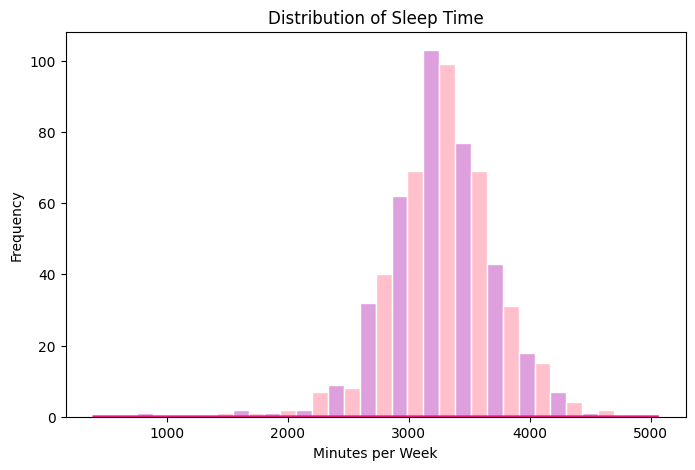

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sleep_data = df["sleep_response"].dropna()

plt.figure(figsize=(8, 5))

ax = sns.histplot(
    sleep_data,
    bins=30,
    kde=False,
    edgecolor="white",
    linewidth=1
)

colors = ["plum", "pink"]

for i, bar in enumerate(ax.patches):
    bar.set_facecolor(colors[i % 2])

sns.kdeplot(
    sleep_data,
    color="deeppink",
    linewidth=2
)

plt.title("Distribution of Sleep Time")
plt.xlabel("Minutes per Week")
plt.ylabel("Frequency")
plt.show()

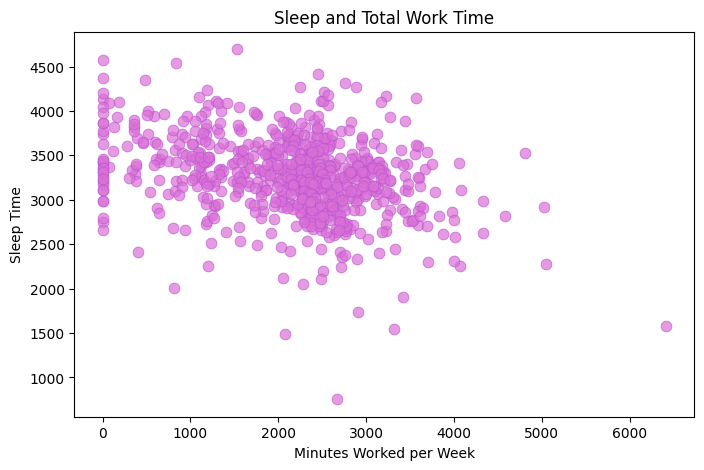

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="totwrk",
    y="sleep_response",
    color="orchid",        
    s=60,                  
    alpha=0.7,             
    edgecolor="mediumorchid"
)

plt.title("Sleep and Total Work Time")
plt.xlabel("Minutes Worked per Week")
plt.ylabel("Sleep Time")
plt.show()

C:\Users\alicj\AppData\Local\Temp\ipykernel_13284\2639141388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


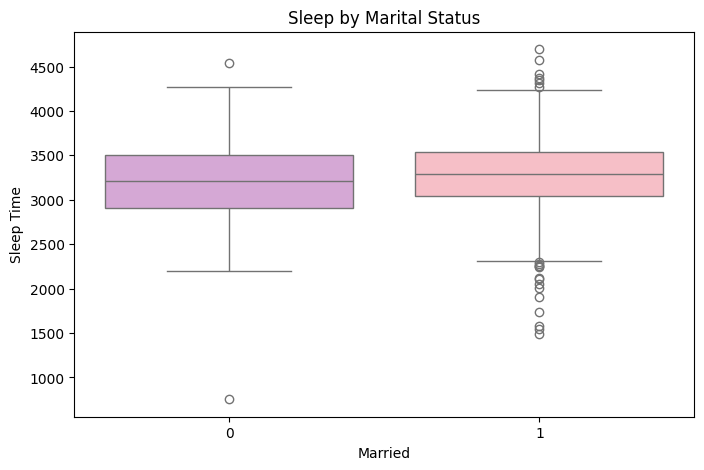

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="marr",
    y="sleep_response",
    palette=["plum", "lightpink"]
)

plt.title("Sleep by Marital Status")
plt.xlabel("Married")
plt.ylabel("Sleep Time")
plt.show()

C:\Users\alicj\AppData\Local\Temp\ipykernel_13284\770192445.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


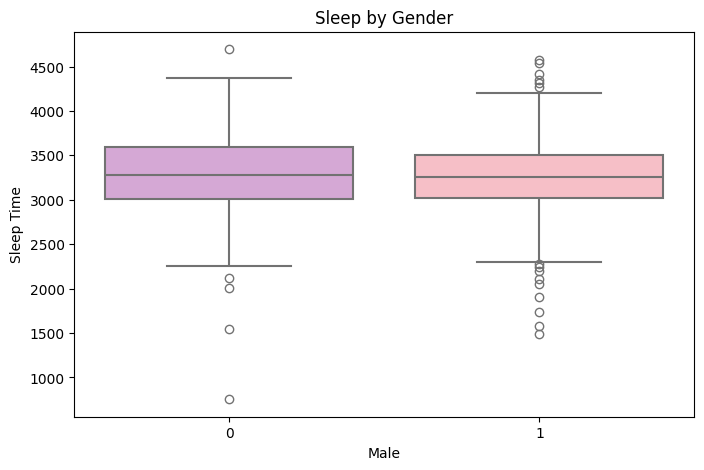

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="male",
    y="sleep_response",
    palette=["plum", "lightpink"],
    linewidth=1.5
)

plt.title("Sleep by Gender")
plt.xlabel("Male")
plt.ylabel("Sleep Time")
plt.show()

C:\Users\alicj\AppData\Local\Temp\ipykernel_13284\2384972137.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


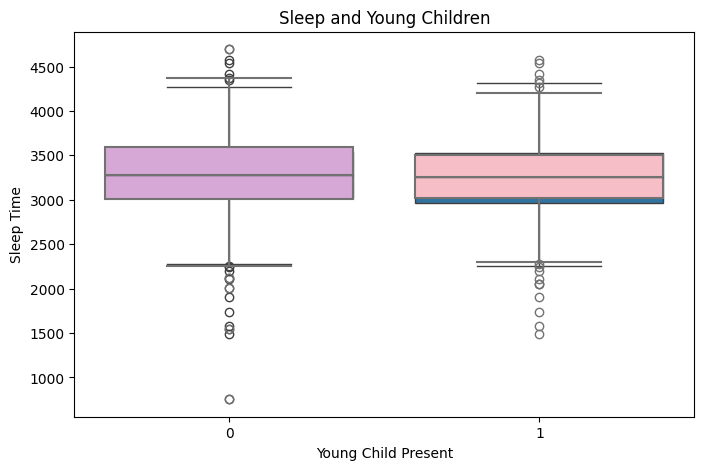

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="yngkid",
    y="sleep_response"
)

sns.boxplot(
    data=df,
    x="male",
    y="sleep_response",
    palette=["plum", "lightpink"],
    linewidth=1.5
)

plt.title("Sleep and Young Children")
plt.xlabel("Young Child Present")
plt.ylabel("Sleep Time")
plt.show()

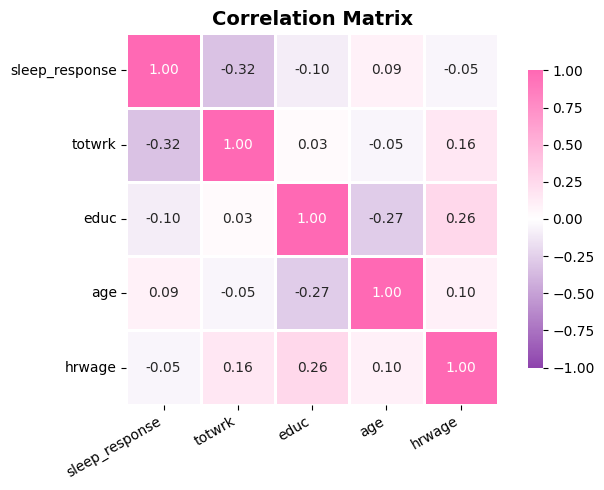

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

corr_vars = [
    "sleep_response",
    "totwrk",
    "educ",
    "age",
    "hrwage"
]

corr = df[corr_vars].corr()

pink_purple_cmap = LinearSegmentedColormap.from_list(
    "pink_purple",
    ["#8e44ad", "#ffffff", "#ff69b4"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap=pink_purple_cmap,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
import statsmodels.formula.api as smf
formula = 'sleep_response ~ totwrk + educ + age + male + marr'

model = smf.ols(formula=formula, data=df)

results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         sleep_response   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     19.50
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           3.29e-18
Time:                        21:51:10   Log-Likelihood:                -5259.5
No. Observations:                 706   AIC:                         1.053e+04
Df Residuals:                     700   BIC:                         1.056e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3615.4221    117.938     30.655      0.0

In [18]:
r_squared = results.rsquared
f_pvalue = results.f_pvalue

print(f"R-kwadrat (R²): {r_squared:.4f}")

print(f"\np-value dla testu F: {f_pvalue:.4e}")


R-kwadrat (R²): 0.1223

p-value dla testu F: 3.2907e-18


Interpretacja: Model wyjaśnia w przybliżeniu 12.23% wariancji zmiennej zależnej (sleep_response).
Wniosek: P-value < 0.05. Model jako całość jest istotny statystycznie.

[Wyraz wolny / Intercept]: szacowana wartość wyrazu wolnego w tym modelu wynosi 3615.42.

totwrk: Istotny statystycznie wzrost czasu pracy o jedną jednostkę powoduje średni spadek czasu snu o 0.16 minut

educ: Poziom edukacji ma istotny statystycznie wpływ na sen, gdzie jego wzrost o jedną jednostkę skraca czas snu średnio o 11.60 minut

age: Wiek nie wykazuje istotnego statystycznie wpływu na czas snu

male: Płeć męska jest istotna statystycznie i wiąże się ze średnim wydłużeniem czasu snu o 83.14 minut

marr: Stan cywilny (małżeństwo) nie wpływa w sposób istotny statystycznie na czas snu